# 1D Fokker-Planck Equation

The fokker-Planck equation(FPE) describes the evolution of a density in the presence of diffusion and a drift in a special form given by a $\mathit{potential}$. Let $\rho(x,t)$ denote the concentration of a particles, then the FPE is given by
$$\partial_t \rho = \partial _x \cdot (\partial_x \rho+\rho \partial_x V),$$
where $V(x)$ is a given smooth potential. The equation is particularly common to describe the evolution of probability densities of particles performing a random walk (Brownian motion) in an energy landscape given by V: They are pushed around by thermal noise, leading to diffusion, but simultaneously are trying to minimise their own potential energy by flowing to regions of low $V$.

# Stochastic Differential Equations(SDEs)

$$dX(t)=b(X(t))dt+\sigma (X(t))dW(t), \qquad  t \geq 0$$
$$X(0)=X_0,\tag{1}$$
are characterized by a right-hand side depending on two terms:
  - the function $b:\mathbb{R}^d \to \mathbb{R}^d,$ well known as $\mathit{drift}$ of the problem, that is the coefficients of its deterministic part;
  - the function $\sigma:\mathbb{R}^d \to \mathbb{R}^{d\times m},$ denoted in the literature as $\mathit{diffusion}$ of the problem, that is the coeeficient of its stochastic part.
The term $W(t)$ is  a $m$-dimensional standard Wiener process and, due to its nowhere differentiability, the representation given above is a shorthand notation for its integral counterpart
$$X(t)=X(0)+\int_0^t b(X(s))ds+ \int_0^t \sigma(X(s))dW(s) $$


# Markov Generator

$\mathcal{L} (\phi) = b \phi' + \frac{1}{2} \sigma^2 \phi'' \Leftrightarrow  \partial_t \rho = \mathcal{L}^* (\rho) = - \partial_x (b\rho) +\frac{1}{2}\partial_{xx}(\sigma^2 \rho) $

## Ornstein–Uhlenbeck Process

$$ dX_t = -\kappa X_t dt + \sqrt{2D} dW_t \Leftrightarrow   \partial_t \rho = \kappa \partial_x(x\rho)+D\rho_{xx}$$
$$ J = -\kappa x\rho - D \rho_{x}, \qquad \rho_t=-\partial_x J$$
which subjects to the zero-flux boundary conditions:
$$J(x_L,t)=J(x_R,t)=0$$
and inital data 
$$\rho(x,0) = \frac{1}{\sqrt{2\pi} s_0} \exp(-\frac{1}{2} (\frac{x-m_0}{s_0})^2)  $$
with $m_0=-2$ and $s_0=0.5$.

In [1]:
k = 1
D = 1

x_L = -5
x_R = 5
m0 = -2.0
s0 = 0.5
T=3


### Finite Difference

$x_i = x_L+ih, \quad \rho_i(t)=\rho(x_i,t).$

In [2]:
import numpy as np

In [3]:
#spatial size
Nx = 200
x=np.linspace(x_L,x_R,Nx+1)
dx=x[1]-x[0] 


#temporal size
Nt=6000
dt=T/Nt


# Initial Gaussian density
rho = (
    np.exp(-0.5 * ((x - m0) / s0)**2)
    / (np.sqrt(2 * np.pi) * s0)
)

rho /= np.trapz(rho, x)

In [4]:
# discretisation of the first derivative
A=np.zeros( (Nx+1,Nx+1) )
for j in range(Nx+1):
    if j == 0:
        A[0,0] = -k**2 * dt / D * (x_L-dx)*x_L
        A[0,1] = k * dt 
    elif j == Nx:
        A[j,j] = - k**2 * dt / D * x_R * (x_R+dx)
        A[j,j-1] = k * dt 
    else:
        A[j,j-1] = -k * dt / (2*dx) * (x_L+(j-1)*dx)
        A[j,j+1] = +k * dt / (2*dx) * (x_L+(j+1)*dx)

#discretisation of the second derivative      
B=np.zeros( (Nx+1,Nx+1) )
for j in range(Nx+1):
    if j == 0:
        B[0,0] = 2 * k * dx / D * x_L -2
        B[0,1] = 2 
    elif j == Nx:
        B[j,j] =  -2 * dx * k / D * x_R - 2
        B[j,j-1] = 2
    else:
        B[j,j-1] = 1
        B[j,j]   = -2
        B[j,j+1] = 1    
# Identity
I = np.eye(Nx + 1)

#Assemble
M = A + D * dt / (dx**2)*B + I

In [5]:
rho_n = rho.copy()

snapshots = {0.0: rho_n.copy()}
save_times = [0.5, 1.0, 2.0, 3.0]
save_steps = {
    int(round(t / dt)): t
    for t in save_times
}

mass_history = [np.trapz(rho_n, x)]
minimum_history = [rho_n.min()]

for n in range(Nt):

    rho_n = M @ rho_n

    mass_history.append(np.trapz(rho_n, x))
    minimum_history.append(rho_n.min())

    step = n + 1

    if step in save_steps:
        t = save_steps[step]
        snapshots[t] = rho_n.copy()

In [6]:
print("Initial mass:", mass_history[0])
print("Final mass:", mass_history[-1])
print("Minimum value:", min(minimum_history))

Initial mass: 0.9999999999999999
Final mass: 1.000002029708733
Minimum value: 2.1932131210080036e-43


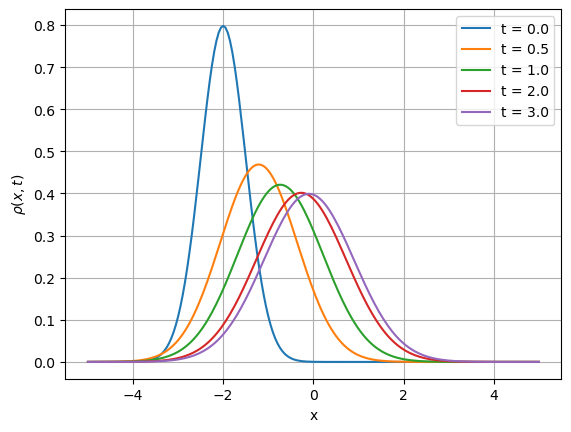

In [7]:
import matplotlib.pyplot as plt

for t, rho_t in snapshots.items():
    plt.plot(x, rho_t, label=f"t = {t}")

plt.xlabel("x")
plt.ylabel(r"$\rho(x,t)$")
plt.legend()
plt.grid()
plt.show()

In [8]:
# exact solution
def exact_ou_density(x, t, k, D, m0, s0):
    mean = m0 * np.exp(-k * t)

    variance = (
        s0**2 * np.exp(-2 * k * t)
        + D / k * (1 - np.exp(-2 * k * t))
    )

    return (
        np.exp(-(x - mean)**2 / (2 * variance))
        / np.sqrt(2 * np.pi * variance)
    )

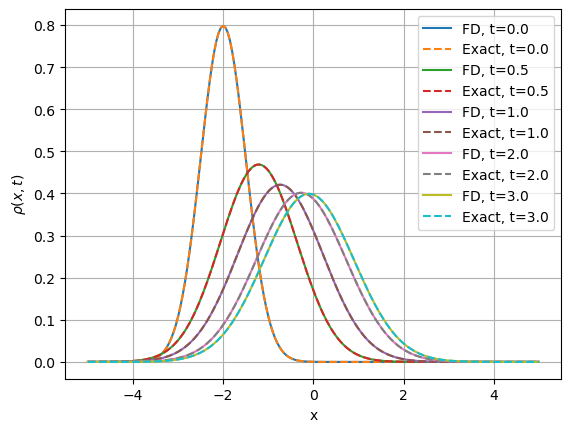

L1 error: 0.0001462327537259038
Linf error: 5.9011155047139496e-05


In [9]:
#plot

for t, rho_num in snapshots.items():
    rho_exact = exact_ou_density(x, t, k, D, m0, s0)

    plt.plot(x, rho_num, label=f"FD, t={t}")
    plt.plot(x, rho_exact, "--", label=f"Exact, t={t}")

plt.xlabel("x")
plt.ylabel(r"$\rho(x,t)$")
plt.legend()
plt.grid()
plt.show()

#error
t_eval = T
rho_num = snapshots[t_eval]
rho_exact = exact_ou_density(x, t_eval, k, D, m0, s0)
error = rho_num - rho_exact
L1_error = np.trapz(np.abs(error), x)
Linf_error = np.max(np.abs(error))
print('L1 error:', L1_error)
print('Linf error:', Linf_error)

### Euler-Maruyama 

In [10]:
import numpy as np
import matplotlib.pyplot as plt

In [11]:
def f(x):
    return -k * x
def g(x):
    return np.sqrt(2*D)

rng = np.random.default_rng(319)

In [12]:
def eulermaruyama_ensemble(T, X0, N, f, g,save_times):
    

    dt = T / N

    X_current = np.asarray(X0, dtype=float).copy()
    
    save_steps = {int(round(t / dt)): t for t in save_times}
    
    # save initial data
    snapshots = {0.0: X_current.copy()}

    for n in range(N):
        
        #  Wiener increment
        dW = np.sqrt(dt) * rng.standard_normal(X_current.size)

        # Euler-Maruyama update
        X_current = (X_current + dt * f(X_current) + g(X_current) * dW )

        step = n + 1

        if step in save_steps:
            t_save = save_steps[step]
            snapshots[t_save] = X_current.copy()

    return snapshots, dt

In [14]:
num_paths=60000

#Euler-Maruyama step size
N_em=6000


#time for plotting
save_times_em=[0.0,0.5,1.0,2.0,3.0]

# SDE initial data
X0=rng.normal(loc=m0,scale=s0,size=num_paths)

em_snapshots, dt_em = eulermaruyama_ensemble(T,X0,N_em,f,g,save_times_em)

In [15]:
# Histogram bin boundaries centred at the FD grid points
bin_edges = np.linspace(x_L - dx / 2, x_R + dx / 2, Nx + 2)

em_density_snapshots = {}

for t, samples in em_snapshots.items():

    counts, _ = np.histogram(samples,bins=bin_edges)

    # Probability density = number of particles / (total particles × bin width)
    rho_em = counts / (num_paths * dx)

    em_density_snapshots[t] = rho_em

In [16]:
for t, rho_em in em_density_snapshots.items():

    mass_em = np.sum(rho_em) * dx

    print(
        f"t = {t}, "
        f"EM density mass = {mass_em}"
    )

t = 0.0, EM density mass = 1.0
t = 0.5, EM density mass = 0.9999999999999997
t = 1.0, EM density mass = 1.0
t = 2.0, EM density mass = 1.0
t = 3.0, EM density mass = 1.0


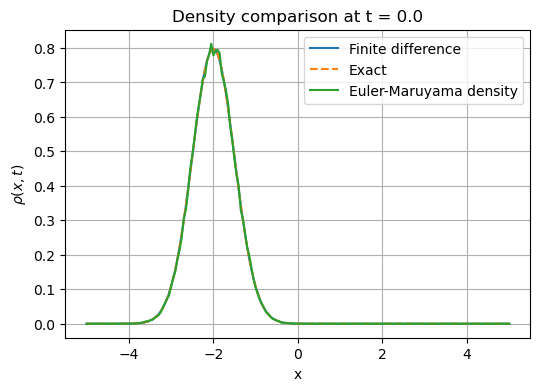

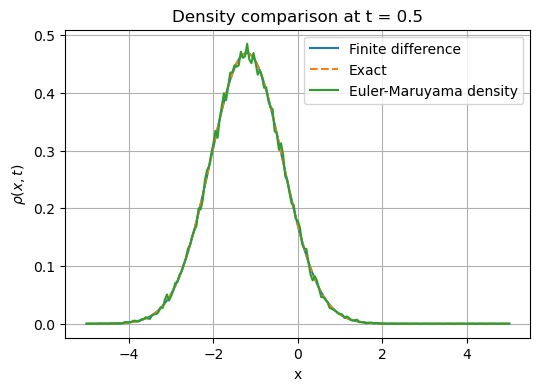

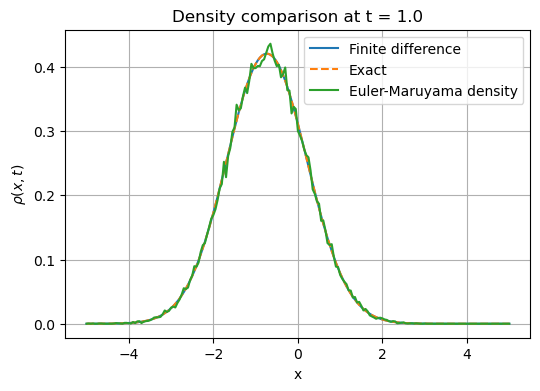

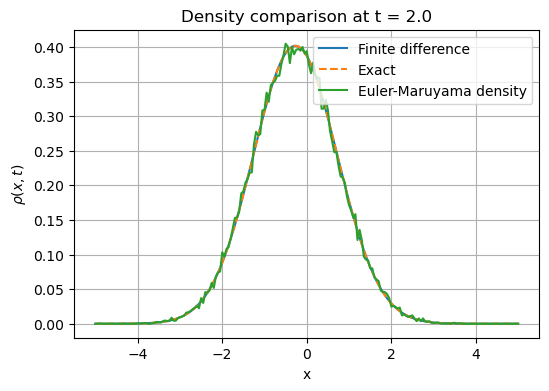

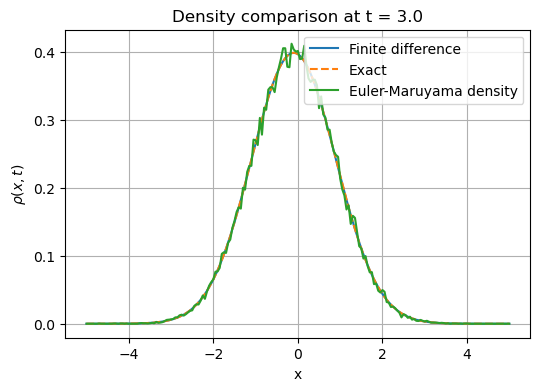

In [20]:
comparison_times = [0.0, 0.5, 1.0, 2.0, 3.0]

for t in comparison_times:

    rho_fd = snapshots[t]

    rho_em = em_density_snapshots[t]

    rho_exact = exact_ou_density(x,t,k,D,m0, s0)

    plt.figure(figsize=(6, 4))

    plt.plot(x,rho_fd,label="Finite difference")

    plt.plot(x,rho_exact,"--",label="Exact")

    plt.plot(x,rho_em,label="Euler-Maruyama density")

    plt.xlabel("x")
    plt.ylabel(r"$\rho(x,t)$")
    plt.title(f"Density comparison at t = {t}")

    plt.legend()
    plt.grid()
    plt.show()

In [18]:
for t in comparison_times:

    rho_fd = snapshots[t]

    rho_em = em_density_snapshots[t]

    rho_exact = exact_ou_density(x,t,k,D,m0,s0)

    fd_error = rho_fd - rho_exact
    em_error = rho_em - rho_exact

    fd_L1 = np.trapz( np.abs(fd_error),x)

    fd_Linf = np.max(np.abs(fd_error))

    em_L1 = np.trapz( np.abs(em_error), x)
    em_Linf = np.max(np.abs(em_error))
    print(f"t = {t}")
    print(f"FD L1 error   = {fd_L1}")
    print(f"FD Linf error = {fd_Linf}")
    print(f"EM L1 error   = {em_L1}")
    print(f"EM Linf error = {em_Linf}")
    print()

t = 0.0
FD L1 error   = 1.0168008651060324e-09
FD Linf error = 8.112897020851051e-10
EM L1 error   = 0.017171626444878112
EM Linf error = 0.021557702412287938

t = 0.5
FD L1 error   = 0.00014321292768356114
FD Linf error = 6.136464424633115e-05
EM L1 error   = 0.027877432621636455
EM Linf error = 0.016454505952735343

t = 1.0
FD L1 error   = 0.00014100757755803678
FD Linf error = 4.012596970731641e-05
EM L1 error   = 0.027813597930610796
EM Linf error = 0.024477487902578754

t = 2.0
FD L1 error   = 0.00014577380280637547
FD Linf error = 5.17949310106236e-05
EM L1 error   = 0.03354478126101702
EM Linf error = 0.02165233225617358

t = 3.0
FD L1 error   = 0.0001462327537259038
FD Linf error = 5.9011155047139496e-05
EM L1 error   = 0.034154006889741614
EM Linf error = 0.022619906803858114



## Geometric Brownian Motion

Let us consider the case of linear drift and diffusion, i.e.,
$$dX(t)=\mu X(t)dt+ \sigma X(t) dW(t), \qquad \mu,\sigma \in \mathbb{R}$$
$$X(0)=X_0.$$
well known as the equation of $\mathit{geometric \ Brownian \ motion}$.
If $\mu$ and $\sigma$ are both non-zero, the exact solution is given by 
$$X(t)=X_0 e^{ (\mu - \frac{1}{2} \sigma ^2 )t +\sigma W(t)}$$
The corresponding $\mathit{FPE}$ is 
$$\partial_t \rho = -\partial_x (\mu x \rho)+ \frac{1}{2} \partial_{xx}(\sigma^2 x^2 \rho)  \tag{2}$$

### Euler-Maruyama

### Finite Difference

$$\partial_t \rho = - \frac{\mu x_{j+1} \rho_{j+1} - \mu x_{j-1} \rho_{j-1}}{2h} + \frac{1}{2} \frac{\sigma^2 x_{j+1}^2 \rho_{j+1} - 2\sigma^2 x_{j}^2 \rho_{j} + \sigma^2 x_{j-1}^2 \rho_{j-1}     }{h^2} $$

backward euler:

$$\frac{\rho_j^{n+1}-\rho_j^{n}}{\delta} = - \frac{\mu x_{j+1} \rho_{j+1}^{n+1} - \mu x_{j-1} \rho_{j-1}^{n+1}}{2h} + \frac{1}{2} \frac{\sigma^2 x_{j+1}^2 \rho_{j+1}^{n+1} - 2\sigma^2 x_{j}^2 \rho_{j}^{n+1} + \sigma^2 x_{j-1}^2 \rho_{j-1} ^{n+1}   }{h^2} $$

In [ ]:
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt

In [ ]:
T = 1.0
X0 = 1.0
N = 1000